# Tabular Modeling

## Data Loading/Preparations

In [1]:
import pandas as pd
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("tabular_data_modeling").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/29 01:11:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/29 01:11:33 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/04/29 01:11:33 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [9]:
# Loading cleaned training/testing sets from tabular_data_cleaning.ipynb
hdfs_path = "hdfs://localhost:9000/user/jj/final_proj/"

train_df = spark.read.parquet(hdfs_path + "train.parquet")
test_df = spark.read.parquet(hdfs_path + "test.parquet")

In [10]:
from pyspark.ml import PipelineModel

pipeline = PipelineModel.load(hdfs_path + "tabular_pipeline.parquet")

In [11]:
train_df.show(5)

+--------------------+------+
|            features|Cancer|
+--------------------+------+
|(15,[0,1,2,3,10],...|     0|
|(15,[0,1,4,10],[3...|     0|
|(15,[0,1,2,3,4,9,...|     1|
|(15,[0,1,2,3,4,11...|     0|
|(15,[0,1,2,3,4,10...|     0|
+--------------------+------+
only showing top 5 rows



## Initial Modeling (Untuned Models)

In [11]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

In [12]:
from pyspark.sql import Row

def append_classification_report(results_df, predictions, model_name):
    """
    Appends a new row of classification metrics to an existing Spark DataFrame.
    
    Parameters:
        results_df (DataFrame): Spark DataFrame holding previous model metrics
        predictions (DataFrame): Predictions output from a model
        model_name (str): Name of the model for reporting
        
    Returns:
        DataFrame: Updated Spark DataFrame with the new model's metrics appended
    """

    # Evaluators
    auc_eval = BinaryClassificationEvaluator(labelCol="Cancer", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    acc_eval = MulticlassClassificationEvaluator(labelCol="Cancer", predictionCol="prediction", metricName="accuracy")
    f1_eval = MulticlassClassificationEvaluator(labelCol="Cancer", predictionCol="prediction", metricName="f1")
    prec_eval = MulticlassClassificationEvaluator(labelCol="Cancer", predictionCol="prediction", metricName="precisionByLabel")
    rec_eval = MulticlassClassificationEvaluator(labelCol="Cancer", predictionCol="prediction", metricName="recallByLabel")

    # Metrics
    auc = auc_eval.evaluate(predictions)
    acc = acc_eval.evaluate(predictions)
    f1 = f1_eval.evaluate(predictions)
    prec = prec_eval.evaluate(predictions)
    rec = rec_eval.evaluate(predictions)

    # Create a new row
    row = Row("Model", "AUC", "Accuracy", "F1", "Precision", "Recall")
    new_row = predictions.sparkSession.createDataFrame([row(model_name, auc, acc, f1, prec, rec)])

    # Append to existing results_df
    updated_df = results_df.unionByName(new_row)

    return updated_df


In [13]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

# Creating a results dataframe for easy comparison
schema = StructType([
    StructField("Model", StringType(), True),
    StructField("AUC", DoubleType(), True),
    StructField("Accuracy", DoubleType(), True),
    StructField("F1", DoubleType(), True),
    StructField("Precision", DoubleType(), True),
    StructField("Recall", DoubleType(), True)
])

results_df = spark.createDataFrame([], schema)

### Model 1: Logistic Regression

In [14]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol='Cancer', featuresCol='features')

lr_model = lr.fit(train_df)

predictions = lr_model.transform(test_df)

25/04/18 15:50:34 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/04/18 15:50:34 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
                                                                                

In [15]:
# Evaluation
lr_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
lr_auc = lr_binary.evaluate(predictions)

lr_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
lr_acc = lr_multi_acc.evaluate(predictions)

lr_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
lr_f1 = lr_multi_f1.evaluate(predictions)

print("Logistic Regression Results:")
print("Area Under ROC - " + str(lr_auc))
print("Accuracy - " + str(lr_acc))
print("F1 - " + str(lr_f1))

Logistic Regression Results:
Area Under ROC - 0.8197202454064763
Accuracy - 0.7251747329552948
F1 - 0.7739803843772705


In [16]:
results_df = append_classification_report(results_df, predictions, "Logistic Regression")

### Model 2: Random Forest

In [17]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(labelCol='Cancer', featuresCol='features')

rf_model = rf.fit(train_df)

predictions = rf_model.transform(test_df)

In [18]:
# Evaluation
rf_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
rf_auc = rf_binary.evaluate(predictions)

rf_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
rf_acc = rf_multi_acc.evaluate(predictions)

rf_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
rf_f1 = rf_multi_f1.evaluate(predictions)

print("Random Forest Results:")
print("Area Under ROC - " + str(rf_auc))
print("Accuracy - " + str(rf_acc))
print("F1 - " + str(rf_f1))

Random Forest Results:
Area Under ROC - 0.8154486145317402
Accuracy - 0.7059211393907424
F1 - 0.7592212019522869


In [19]:
results_df = append_classification_report(results_df, predictions, "Random Forest")

### Model 3: Gradient Boosted Trees

In [20]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(labelCol='Cancer', featuresCol='features')

gbt_model = gbt.fit(train_df)

predictions = gbt_model.transform(test_df)

In [21]:
# Evaluation
gbt_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
gbt_auc = gbt_binary.evaluate(predictions)

gbt_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
gbt_acc = gbt_multi_acc.evaluate(predictions)

gbt_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
gbt_f1 = gbt_multi_f1.evaluate(predictions)

print("Gradient Boosted Trees Results:")
print("Area Under ROC - " + str(gbt_auc))
print("Accuracy - " + str(gbt_acc))
print("F1 - " + str(gbt_f1))

Gradient Boosted Trees Results:
Area Under ROC - 0.815917330855832
Accuracy - 0.7185810365290782
F1 - 0.7689224853170217


In [22]:
results_df = append_classification_report(results_df, predictions, "GBT")

### Model 4: Naive Bayes

In [23]:
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(labelCol='Cancer', featuresCol='features')

nb_model = nb.fit(train_df)

predictions = nb_model.transform(test_df)

In [24]:
# Evaluation
nb_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
nb_auc = nb_binary.evaluate(predictions)

nb_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
nb_acc = nb_multi_acc.evaluate(predictions)

nb_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
nb_f1 = nb_multi_f1.evaluate(predictions)

print("Naive Bayes Results:")
print("Area Under ROC - " + str(nb_auc))
print("Accuracy - " + str(nb_acc))
print("F1 - " + str(nb_f1))

Naive Bayes Results:
Area Under ROC - 0.4313106515087149
Accuracy - 0.6871950415402874
F1 - 0.7439943131537241


In [25]:
results_df = append_classification_report(results_df, predictions, "Naive Bayes")

### Model 5: Multilayer Perceptron

In [26]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

layers = [len(train_df.select("features").first()[0]), 5, 2]

mlpc = MultilayerPerceptronClassifier(
    featuresCol='features',
    labelCol='Cancer',
    layers=layers,
    seed=101
)

mlpc_model = mlpc.fit(train_df)

predictions = mlpc_model.transform(test_df)

In [27]:
# Evaluation
mlpc_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
mlpc_auc = mlpc_binary.evaluate(predictions)

mlpc_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
mlpc_acc = mlpc_multi_acc.evaluate(predictions)

mlpc_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
mlpc_f1 = mlpc_multi_f1.evaluate(predictions)

print("Multilayer Perceptron Results:")
print("Area Under ROC - " + str(mlpc_auc))
print("Accuracy - " + str(mlpc_acc))
print("F1 - " + str(mlpc_f1))

Multilayer Perceptron Results:
Area Under ROC - 0.8131799263864274
Accuracy - 0.7134379533166293
F1 - 0.7651381713397933


In [28]:
results_df = append_classification_report(results_df, predictions, "Multilayer Perceptron")

### Model 6: SVM

In [29]:
from pyspark.ml.classification import LinearSVC

svm = LinearSVC(labelCol='Cancer', featuresCol='features')

svm_model = svm.fit(train_df)

predictions = svm_model.transform(test_df)

In [30]:
# Evaluation
svm_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
svm_auc = svm_binary.evaluate(predictions)

svm_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
svm_acc = svm_multi_acc.evaluate(predictions)

svm_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
svm_f1 = svm_multi_f1.evaluate(predictions)

print("SVM Results:")
print("Area Under ROC - " + str(svm_auc))
print("Accuracy - " + str(svm_acc))
print("F1 - " + str(svm_f1))

SVM Results:
Area Under ROC - 0.8192748079623176
Accuracy - 0.71132797046024
F1 - 0.7634904970541858


In [31]:
results_df = append_classification_report(results_df, predictions, "SVM")

### Bonus: Logistic Regression with classWeightCol

In [32]:
from pyspark.sql.functions import when, col

weighted_df = train_df.withColumn("classWeightCol", when(col("Cancer") == 1, 2.0).otherwise(1.0))

In [33]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(labelCol='Cancer', featuresCol='features', weightCol='classWeightCol')

lr_model = lr.fit(weighted_df)

predictions = lr_model.transform(test_df)

In [34]:
# Evaluation
lr_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
lr_auc = lr_binary.evaluate(predictions)

lr_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
lr_acc = lr_multi_acc.evaluate(predictions)

lr_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
lr_f1 = lr_multi_f1.evaluate(predictions)

print("Weighted Logistic Regression Results:")
print("Area Under ROC - " + str(lr_auc))
print("Accuracy - " + str(lr_acc))
print("F1 - " + str(lr_f1))

Weighted Logistic Regression Results:
Area Under ROC - 0.8193484808220377
Accuracy - 0.5892127126467097
F1 - 0.661826013736026


### Result Evaluation

In [35]:
results_df.orderBy('F1').show()

[Stage 719:===================================================>   (13 + 1) / 14]

+--------------------+------------------+------------------+------------------+------------------+------------------+
|               Model|               AUC|          Accuracy|                F1|         Precision|            Recall|
+--------------------+------------------+------------------+------------------+------------------+------------------+
|         Naive Bayes|0.4313148364758947|0.6871950415402874|0.7439943131537241|0.9520846297448662|0.6819194770465012|
|       Random Forest|0.8154486145317402|0.7059211393907424|0.7592212019522869|0.9646913070410902|0.6941019165057198|
|                 SVM|0.8192634736762076|  0.71132797046024|0.7634904970541858|0.9657506152584086| 0.699598870895855|
|Multilayer Percep...|0.8131790545182658|0.7134379533166293|0.7651381713397933|0.9658626328699919|0.7019759322537513|
|                 GBT|0.8159194233394217|0.7185810365290782|0.7689224853170217|0.9625679211108875|0.7105927796761254|
| Logistic Regression|0.8197261741099786|0.7251747329552

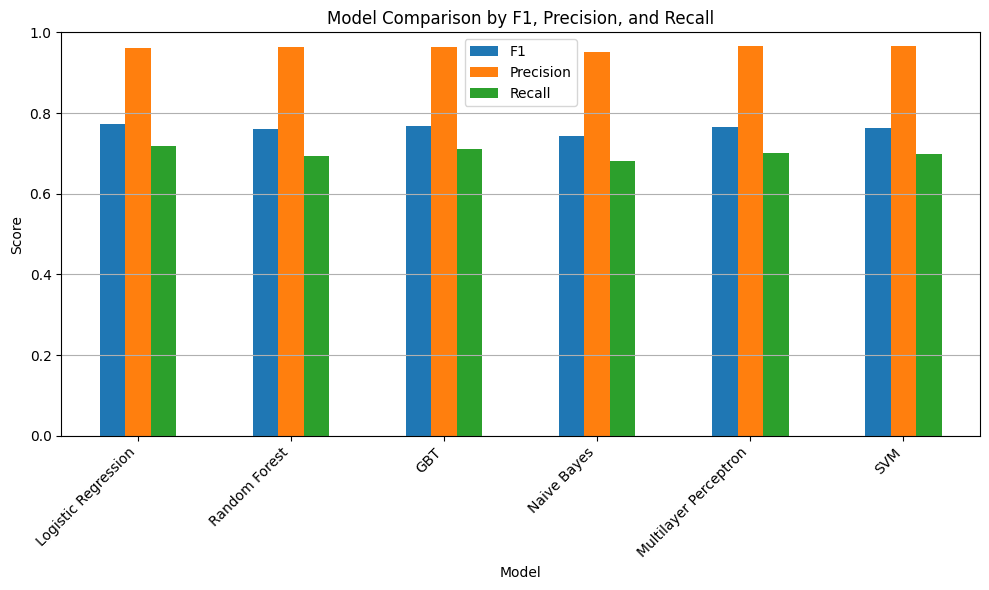

In [36]:
# Convert Spark DataFrame to Pandas
pandas_df = results_df.toPandas()

# Plotting F1, Recall, and AUC
import matplotlib.pyplot as plt

metrics_to_plot = ["F1", "Precision", "Recall"]
pandas_df.set_index("Model")[metrics_to_plot].plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison by F1, Precision, and Recall")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y')
plt.show()


## Model Tuning

In [30]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [56]:
# Tuned Results Dataframe
schema = StructType([
    StructField("Model", StringType(), True),
    StructField("AUC", DoubleType(), True),
    StructField("Accuracy", DoubleType(), True),
    StructField("F1", DoubleType(), True),
    StructField("Precision", DoubleType(), True),
    StructField("Recall", DoubleType(), True)
])

tuned_results_df = spark.createDataFrame([], schema)

### Model 1: Random Forest

In [53]:
rf = RandomForestClassifier(labelCol='Cancer', featuresCol='features', seed=101)

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [50, 100]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .addGrid(rf.minInstancesPerNode, [1, 5]) \
    .addGrid(rf.featureSubsetStrategy, ["sqrt", "log2"]) \
    .build()

evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer",
    predictionCol="prediction",
    metricName="f1"
)

cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=1,
    seed=101
)

cv_model = cv.fit(train_df)

25/04/18 03:42:27 WARN DAGScheduler: Broadcasting large task binary with size 1248.6 KiB
25/04/18 03:42:28 WARN DAGScheduler: Broadcasting large task binary with size 1862.6 KiB
25/04/18 03:42:29 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/04/18 03:42:31 WARN DAGScheduler: Broadcasting large task binary with size 1580.4 KiB
25/04/18 03:42:35 WARN DAGScheduler: Broadcasting large task binary with size 1248.6 KiB
25/04/18 03:42:37 WARN DAGScheduler: Broadcasting large task binary with size 1862.6 KiB
25/04/18 03:42:39 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/04/18 03:42:41 WARN DAGScheduler: Broadcasting large task binary with size 1580.4 KiB
25/04/18 03:42:46 WARN DAGScheduler: Broadcasting large task binary with size 1146.5 KiB
25/04/18 03:42:47 WARN DAGScheduler: Broadcasting large task binary with size 1628.8 KiB
25/04/18 03:42:49 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
25/04/18 03:42:51 WARN DAGSche

In [54]:
best_rf_model = cv_model.bestModel
rf_predictions = best_rf_model.transform(test_df)

f1_score = evaluator.evaluate(rf_predictions)
print(f"Best F1 Score on Test Data: {f1_score:.4f}")

25/04/18 03:50:08 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
[Stage 8620:>                                                       (0 + 2) / 2]

Best F1 Score on Test Data: 0.7827


In [55]:
best_params = best_rf_model.extractParamMap()

# Print each parameter that was set --> Prevents the need to rerun
for param, value in best_params.items():
    print(f"{param.name}: {value}")

bootstrap: True
cacheNodeIds: False
checkpointInterval: 10
featureSubsetStrategy: sqrt
featuresCol: features
impurity: gini
labelCol: Cancer
leafCol: 
maxBins: 32
maxDepth: 10
maxMemoryInMB: 256
minInfoGain: 0.0
minInstancesPerNode: 1
minWeightFractionPerNode: 0.0
numTrees: 100
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
seed: 101
subsamplingRate: 1.0


In [57]:
tuned_results_df = append_classification_report(tuned_results_df, rf_predictions, "Random Forest")

25/04/18 03:53:00 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 03:53:03 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
25/04/18 03:53:06 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
25/04/18 03:53:08 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
25/04/18 03:53:10 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
                                                                                

In [ ]:
# Best params:
# Numtrees: 100
# Maxdepth: 10
# MinINstance: 1
# SubsetStrat: sqrt

### Model 2: Logistic Regression

In [60]:
lr = LogisticRegression(labelCol='Cancer', featuresCol='features')

paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .addGrid(lr.maxIter, [50, 100]) \
    .build()

evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer",
    predictionCol="prediction",
    metricName="f1"
)

cv = CrossValidator(
    estimator=lr,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=1,
    seed=101
)

cv_model = cv.fit(train_df)

In [61]:
best_lr_model = cv_model.bestModel
lr_predictions = best_lr_model.transform(test_df)

f1_score = evaluator.evaluate(lr_predictions)
print(f"Best F1 Score on Test Data: {f1_score:.4f}")

Best F1 Score on Test Data: 0.7720


In [62]:
best_params = best_lr_model.extractParamMap()

# Print each parameter that was set --> Prevents the need to rerun
for param, value in best_params.items():
    print(f"{param.name}: {value}")

aggregationDepth: 2
elasticNetParam: 0.5
family: auto
featuresCol: features
fitIntercept: True
labelCol: Cancer
maxBlockSizeInMB: 0.0
maxIter: 50
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
regParam: 0.01
standardization: True
threshold: 0.5
tol: 1e-06


In [63]:
tuned_results_df = append_classification_report(tuned_results_df, lr_predictions, "Logistic Regression")

In [ ]:
# Best params:
# regParam: 0.01
# elastic: 0.5
# maxIter: 50

### Model 3: Gradient Boosted Trees

In [68]:
gbt = GBTClassifier(labelCol='Cancer', featuresCol='features')

paramGrid = ParamGridBuilder() \
    .addGrid(gbt.maxIter, [20, 50, 100]) \
    .addGrid(gbt.maxDepth, [3, 5, 7]) \
    .addGrid(gbt.stepSize, [0.05, 0.1]) \
    .build()

evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer",
    predictionCol="prediction",
    metricName="f1"
)

cv = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=1,
    seed=101
)

cv_model = cv.fit(train_df)

25/04/18 04:05:27 WARN DAGScheduler: Broadcasting large task binary with size 1000.8 KiB
25/04/18 04:05:27 WARN DAGScheduler: Broadcasting large task binary with size 1001.6 KiB
25/04/18 04:05:28 WARN DAGScheduler: Broadcasting large task binary with size 1004.0 KiB
25/04/18 04:05:28 WARN DAGScheduler: Broadcasting large task binary with size 1008.7 KiB
25/04/18 04:05:28 WARN DAGScheduler: Broadcasting large task binary with size 1018.2 KiB
25/04/18 04:05:28 WARN DAGScheduler: Broadcasting large task binary with size 1021.9 KiB
25/04/18 04:05:29 WARN DAGScheduler: Broadcasting large task binary with size 1022.4 KiB
25/04/18 04:05:29 WARN DAGScheduler: Broadcasting large task binary with size 1023.4 KiB
25/04/18 04:05:29 WARN DAGScheduler: Broadcasting large task binary with size 1024.1 KiB
25/04/18 04:05:29 WARN DAGScheduler: Broadcasting large task binary with size 1026.5 KiB
25/04/18 04:05:30 WARN DAGScheduler: Broadcasting large task binary with size 1031.2 KiB
25/04/18 04:05:30 WAR

In [69]:
best_gbt_model = cv_model.bestModel
gbt_predictions = best_gbt_model.transform(test_df)

f1_score = evaluator.evaluate(gbt_predictions)
print(f"Best F1 Score on Test Data: {f1_score:.4f}")

25/04/18 04:40:40 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
[Stage 41894:>                                                      (0 + 2) / 2]

Best F1 Score on Test Data: 0.7830


In [70]:
best_params = best_gbt_model.extractParamMap()

# Print each parameter that was set --> Prevents the need to rerun
for param, value in best_params.items():
    print(f"{param.name}: {value}")

cacheNodeIds: False
checkpointInterval: 10
featureSubsetStrategy: all
featuresCol: features
impurity: variance
labelCol: Cancer
leafCol: 
lossType: logistic
maxBins: 32
maxDepth: 7
maxIter: 100
maxMemoryInMB: 256
minInfoGain: 0.0
minInstancesPerNode: 1
minWeightFractionPerNode: 0.0
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
seed: -516051250147499693
stepSize: 0.1
subsamplingRate: 1.0
validationTol: 0.01


In [71]:
tuned_results_df = append_classification_report(tuned_results_df, gbt_predictions, "GBT")

25/04/18 04:41:41 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 04:41:44 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 04:41:46 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 04:41:48 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 04:41:49 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
                                                                                

### Model 4: Multilayer Perceptron

In [76]:
input_size = len(train_df.select("features").first()[0])  # size of the vector
output_size = 2  # For binary classification

# Define several network topologies
layer_configs = [
    [input_size, 5, output_size],               # 1 hidden layer
    [input_size, 10, 5, output_size],           # 2 hidden layers
    [input_size, 15, 10, 5, output_size],       # deeper network
]


mlp = MultilayerPerceptronClassifier(labelCol="Cancer", featuresCol="features", seed=101)

paramGrid = ParamGridBuilder() \
    .addGrid(mlp.layers, layer_configs) \
    .addGrid(mlp.stepSize, [0.01, 0.1]) \
    .addGrid(mlp.maxIter, [100, 200]) \
    .addGrid(mlp.blockSize, [64, 128]) \
    .build()

cv = CrossValidator(
    estimator=mlp,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=1,
    seed=101
)

cv_model = cv.fit(train_df)


25/04/18 04:59:12 WARN BlockManager: Asked to remove block broadcast_86116_piece0, which does not exist


In [77]:
best_mlp_model = cv_model.bestModel
mlp_predictions = best_mlp_model.transform(test_df)

f1_score = evaluator.evaluate(mlp_predictions)
print(f"Best F1 Score on Test Data: {f1_score:.4f}")

Best F1 Score on Test Data: 0.7627


In [78]:
best_params = best_mlp_model.extractParamMap()

# Print each parameter that was set --> Prevents the need to rerun
for param, value in best_params.items():
    print(f"{param.name}: {value}")

blockSize: 64
featuresCol: features
labelCol: Cancer
maxIter: 100
predictionCol: prediction
probabilityCol: probability
rawPredictionCol: rawPrediction
seed: 101
solver: l-bfgs
stepSize: 0.01
tol: 1e-06
layers: [15, 15, 10, 5, 2]


In [79]:
tuned_results_df = append_classification_report(tuned_results_df, mlp_predictions, "MLP")

### Tuned Result Evaluation

In [80]:
tuned_results_df.orderBy('F1', ascending=False).show()

+-------------------+------------------+------------------+------------------+------------------+------------------+
|              Model|               AUC|          Accuracy|                F1|         Precision|            Recall|
+-------------------+------------------+------------------+------------------+------------------+------------------+
|                GBT|0.7779411077468632|0.7391533693788738|0.7830357358296582|0.9472990777338604| 0.747734363393255|
|      Random Forest|0.8173134533442434|0.7369115125939601|0.7826667681598627|0.9592707525213343|0.7348090922596939|
|Logistic Regression|0.8191071477146937|0.7225372543848081| 0.771996612738761|0.9629777866720032|0.7149012033873124|
|                MLP|0.8212222998766141|0.7102729790320453|0.7626853299453413| 0.966077302631579|0.6981132075471698|
+-------------------+------------------+------------------+------------------+------------------+------------------+



## Building Ensemble

In [15]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier

# Creating a validation set
train_df, val_df = train_df.randomSplit([0.8, 0.2], seed=42)


### Building Models

In [16]:
# Rebuilding models with best params
rf = RandomForestClassifier(
    labelCol='Cancer', 
    featuresCol='features',
    numTrees=100,
    maxDepth=10,
    minInstancesPerNode=1,
    featureSubsetStrategy='sqrt'
)

lr = LogisticRegression(
    labelCol='Cancer', 
    featuresCol='features',
    regParam=0.01,
    elasticNetParam=0.5,
    maxIter=50
)

gbt = GBTClassifier(
    labelCol='Cancer', 
    featuresCol='features',
    maxIter=100,
    maxDepth=7,
    stepSize=0.1
)

In [17]:
rf_model = rf.fit(train_df)

lr_model = lr.fit(train_df)

gbt_model = gbt.fit(train_df)

25/04/29 01:16:33 WARN DAGScheduler: Broadcasting large task binary with size 1511.3 KiB
25/04/29 01:16:37 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
25/04/29 01:16:42 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
25/04/29 01:16:49 WARN DAGScheduler: Broadcasting large task binary with size 5.1 MiB
25/04/29 01:17:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/04/29 01:17:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
25/04/29 01:18:54 WARN DAGScheduler: Broadcasting large task binary with size 1007.1 KiB
25/04/29 01:18:55 WARN DAGScheduler: Broadcasting large task binary with size 1009.7 KiB
25/04/29 01:18:55 WARN DAGScheduler: Broadcasting large task binary with size 1010.2 KiB
25/04/29 01:18:55 WARN DAGScheduler: Broadcasting large task binary with size 1011.2 KiB
25/04/29 01:18:55 WARN DAGScheduler: Broadcasting large task binary with size 10

In [ ]:
# Best params:
# regParam: 0.01
# elastic: 0.5
# maxIter: 50

In [18]:
lr_tuned = LogisticRegression(
    labelCol='Cancer', 
    featuresCol='features', 
    regParam=0.01,
    elasticNetParam=0.5,
    maxIter=50
)

lr_tuned_model = lr_tuned.fit(train_df)

In [20]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Evaluation
predictions = lr_tuned_model.transform(test_df)

lr_binary = BinaryClassificationEvaluator(labelCol='Cancer', metricName='areaUnderROC')
lr_auc = lr_binary.evaluate(predictions)

lr_multi_acc = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='accuracy')
lr_acc = lr_multi_acc.evaluate(predictions)

lr_multi_f1 = MulticlassClassificationEvaluator(labelCol='Cancer', metricName='f1')
lr_f1 = lr_multi_f1.evaluate(predictions)

print("Logistic Regression Results:")
print("Area Under ROC - " + str(lr_auc))
print("Accuracy - " + str(lr_acc))
print("F1 - " + str(lr_f1))

Logistic Regression Results:
Area Under ROC - 0.8190975571649088
Accuracy - 0.726097850454965
F1 - 0.7746784363156842


In [21]:
# Getting feature names out
from pyspark.ml.feature import VectorAssembler

pipeline_stages = pipeline.stages
pipeline_stages

assemblers = [stage for stage in pipeline.stages if isinstance(stage, VectorAssembler)]
all_input_cols = []
for assembler in assemblers:
    all_input_cols.extend(assembler.getInputCols())
all_features = list(dict.fromkeys(all_input_cols))
for feature in all_features:
    print(feature)

Age
BMI
Alcohol/Day
num_features_scaled
Gender
Smokes?
Congestive Heart Failure
Coronary Heart Disease
Heart Attack
Stroke
Thyroid
Race_ohe


In [44]:
# Assuming this is your trained model
print("Intercept:", lr_tuned_model.intercept)

for feature, coeff in zip(all_features, lr_tuned_model.coefficients):
    print(f"{feature}: {coeff:.4f}")


Intercept: -3.8552036306864172
Age: 1.0540
BMI: 0.0000
Alcohol/Day: -0.0082
num_features_scaled: 0.1415
Gender: 0.1242
Smokes?: 0.0421
Congestive Heart Failure: 0.0175
Coronary Heart Disease: 0.0000
Heart Attack: 0.2740
Stroke: 0.3683
Thyroid: 0.4961
Race_ohe: -0.2513


In [6]:
train_df.show()

+--------------------+------+
|            features|Cancer|
+--------------------+------+
|(15,[0,1,2,3,11],...|     1|
|(15,[0,1,3,9,14],...|     0|
|(15,[0,1,2,3,9,14...|     1|
|(15,[0,1,4,10],[4...|     1|
|(15,[0,1,3,12],[2...|     0|
|(15,[0,1,3,4,13],...|     0|
|(15,[0,1,3,4,9,10...|     1|
|(15,[0,1,2,4,10],...|     1|
|(15,[0,1,3,9,10],...|     1|
|(15,[0,1,3,14],[3...|     1|
|(15,[0,1,3,14],[1...|     0|
|(15,[0,1,4,9,14],...|     0|
|(15,[0,1,2,3,10],...|     0|
|(15,[0,1,11],[2.0...|     0|
|(15,[0,1,2,3,4,12...|     0|
|(15,[0,1,2,13],[1...|     0|
|(15,[0,1,2,10],[3...|     0|
|(15,[0,1,2,3,4],[...|     0|
|(15,[0,1,2,3,10],...|     0|
|(15,[0,1,4,9,10],...|     1|
+--------------------+------+
only showing top 20 rows



### Soft Voting Ensemble

In [22]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

# UDF to extract the probability of class 1 from a Vector
def extract_prob_1(probability_vector):
    return float(probability_vector[1])

extract_prob_udf = udf(extract_prob_1, DoubleType())


In [26]:
from pyspark.sql.functions import col, when, monotonically_increasing_id

# 1. Generate predictions for each model (only keep probability column)
rf_preds = rf_model.transform(val_df).select("probability")
gbt_preds = gbt_model.transform(val_df).select("probability")
lr_preds = lr_model.transform(val_df).select("probability")

# 2. Extract probability of class 1 for each model
rf_probs = rf_preds.withColumn("rf_prob", extract_prob_udf(col("probability"))).drop("probability")
gbt_probs = gbt_preds.withColumn("gbt_prob", extract_prob_udf(col("probability"))).drop("probability")
lr_probs = lr_preds.withColumn("lr_prob", extract_prob_udf(col("probability"))).drop("probability")

# 3. Add row IDs to align predictions
base = test_df.withColumn("row_id", monotonically_increasing_id())
rf_probs = rf_probs.withColumn("row_id", monotonically_increasing_id())
gbt_probs = gbt_probs.withColumn("row_id", monotonically_increasing_id())
lr_probs = lr_probs.withColumn("row_id", monotonically_increasing_id())

# 4. Join all probabilities into a single DataFrame
ensemble_df = base \
    .join(rf_probs, "row_id") \
    .join(gbt_probs, "row_id") \
    .join(lr_probs, "row_id")

# 5. Compute average probability
ensemble_df = ensemble_df.withColumn(
    "avg_prob",
    (col("rf_prob") + col("gbt_prob") + col("lr_prob")) / 3
)

# 6. Threshold average probability to make final prediction
ensemble_df = ensemble_df.withColumn(
    "ensemble_prediction",
    when(col("avg_prob") > 0.5, 1).otherwise(0)
)


In [27]:
ensemble_df = ensemble_df.withColumn(
    "ensemble_prediction", col("ensemble_prediction").cast("double")
)


evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer",
    predictionCol="ensemble_prediction",
    metricName="f1"
)

ensemble_f1 = evaluator.evaluate(ensemble_df)
print(f"Ensemble F1 Score: {ensemble_f1:.4f}")


25/04/29 01:29:16 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:29:17 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:29:22 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
[Stage 1624:>                                                       (0 + 2) / 2]

Ensemble F1 Score: 0.5645


In [28]:
# F1 Score
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="f1"
)
f1 = f1_evaluator.evaluate(ensemble_df)

# Accuracy
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="accuracy"
)
accuracy = accuracy_evaluator.evaluate(ensemble_df)

# Precision
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="precisionByLabel"
)
precision = precision_evaluator.evaluate(ensemble_df)

# Recall
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="recallByLabel"
)
recall = recall_evaluator.evaluate(ensemble_df)

# AUC (ROC)
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="Cancer", rawPredictionCol="avg_prob", metricName="areaUnderROC"
)
auc = auc_evaluator.evaluate(ensemble_df)

# Print full report
print("=== Ensemble Classification Report ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC (ROC): {auc:.4f}")


25/04/29 01:29:35 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:29:35 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:29:37 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
25/04/29 01:29:40 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:29:41 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:29:43 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
25/04/29 01:29:47 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:29:48 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:29:49 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
25/04/29 01:29:52 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:29:53 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:29:54 WARN DAGScheduler: Broadcasting larg

=== Ensemble Classification Report ===
Accuracy:  0.4711
F1 Score:  0.5645
Precision: 0.8957
Recall:    0.4626
AUC (ROC): 0.4989


### Threshold Tuning

In [30]:
import numpy as np
# Threshold Tuning
thresholds = np.arange(0.3, 0.91, 0.05)

# Precision
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="precisionByLabel"
)

# Recall
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="recallByLabel"
)


best_f1 = 0.0
best_threshold = 0.5
scores = []

for t in thresholds:
    # Apply threshold
    temp = ensemble_df.withColumn("ensemble_prediction", when(col("avg_prob") > t, 1).otherwise(0).cast("double"))
    
    # Evaluate F1
    precision = precision_evaluator.evaluate(temp)
    recall = recall_evaluator.evaluate(temp)
    f1 = 2 * (precision * recall) / (precision + recall)

    scores.append(f1)
    print(f"Threshold: {t:.2f} → F1: {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f} → F1: {best_f1:.4f}")


25/04/29 01:30:30 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:30:31 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:30:33 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
25/04/29 01:30:40 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:30:41 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:30:43 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
                                                                                

Threshold: 0.30 → F1: 0.4373


25/04/29 01:30:46 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:30:46 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:30:48 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
25/04/29 01:30:52 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:30:52 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:30:54 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
                                                                                

Threshold: 0.35 → F1: 0.4858


25/04/29 01:30:57 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:30:58 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:31:00 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
25/04/29 01:31:03 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:31:04 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:31:05 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
                                                                                

...

Threshold: 0.80 → F1: 0.8606


25/04/29 01:32:34 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:32:35 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:32:37 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
25/04/29 01:32:40 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:32:41 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:32:42 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
                                                                                

Threshold: 0.85 → F1: 0.9159


25/04/29 01:32:45 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:32:46 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:32:49 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
25/04/29 01:32:52 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/29 01:32:53 WARN DAGScheduler: Broadcasting large task binary with size 3.0 MiB
25/04/29 01:32:54 WARN DAGScheduler: Broadcasting large task binary with size 5.0 MiB
[Stage 1788:>                                                       (0 + 2) / 2]

Threshold: 0.90 → F1: 0.9422

Best Threshold: 0.90 → F1: 0.9422


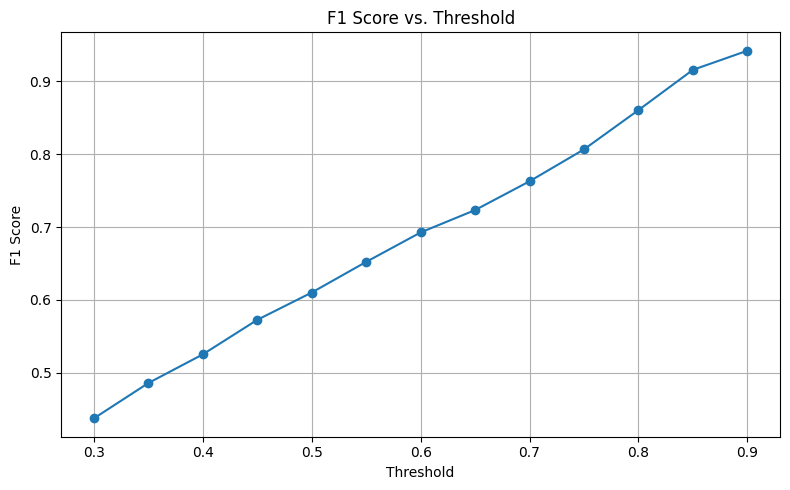

In [31]:
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.arange(0.3, 0.91, 0.05)

plt.figure(figsize=(8, 5))
plt.plot(thresholds[:len(scores)], scores, marker='o')
plt.title("F1 Score vs. Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.grid(True)
plt.tight_layout()
plt.savefig("ensemble_threshold_tuning.png", dpi=300)
plt.show()


In [70]:
# Threshold Tuning
thresholds = np.arange(0.9, 1.0, 0.01)
# Precision
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="precisionByLabel"
)

# Recall
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="recallByLabel"
)

best_f1 = 0.0
best_threshold = 0.5
scores = []

for t in thresholds:
    # Apply threshold
    temp = ensemble_df.withColumn("ensemble_prediction", when(col("avg_prob") > t, 1).otherwise(0).cast("double"))
    
    # Evaluate F1
    precision = precision_evaluator.evaluate(temp)
    recall = recall_evaluator.evaluate(temp)
    f1 = 2 * (precision * recall) / (precision + recall)
    scores.append(f1)
    print(f"Threshold: {t:.2f} → F1: {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"\nBest Threshold: {best_threshold:.2f} → F1: {best_f1:.4f}")


25/04/18 16:55:16 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:55:17 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:55:22 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
25/04/18 16:55:24 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:55:24 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:55:27 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
                                                                                

Threshold: 0.90 → F1: 0.9405


25/04/18 16:55:29 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:55:30 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:55:33 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
25/04/18 16:55:34 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:55:35 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:55:38 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB


Threshold: 0.91 → F1: 0.9405


25/04/18 16:55:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:55:40 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:55:42 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
25/04/18 16:55:45 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:55:46 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:55:48 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
                                                                                

...

Threshold: 0.97 → F1: 0.9405


25/04/18 16:56:47 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:56:47 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:56:51 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
25/04/18 16:56:53 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:56:54 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:56:57 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
                                                                                

Threshold: 0.98 → F1: 0.9405


25/04/18 16:56:59 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:57:00 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:57:03 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
25/04/18 16:57:04 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 16:57:05 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 16:57:08 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB


Threshold: 0.99 → F1: 0.9405

Best Threshold: 0.91 → F1: 0.9405


### Rebuilding Ensemble with Threshold

In [71]:
from pyspark.sql.functions import col, when, monotonically_increasing_id

# 1. Generate predictions for each model (only keep probability column)
rf_preds = rf_model.transform(test_df).select("probability")
gbt_preds = gbt_model.transform(test_df).select("probability")
lr_preds = lr_model.transform(test_df).select("probability")

# 2. Extract probability of class 1 for each model
rf_probs = rf_preds.withColumn("rf_prob", extract_prob_udf(col("probability"))).drop("probability")
gbt_probs = gbt_preds.withColumn("gbt_prob", extract_prob_udf(col("probability"))).drop("probability")
lr_probs = lr_preds.withColumn("lr_prob", extract_prob_udf(col("probability"))).drop("probability")

# 3. Add row IDs to align predictions
base = test_df.withColumn("row_id", monotonically_increasing_id())
rf_probs = rf_probs.withColumn("row_id", monotonically_increasing_id())
gbt_probs = gbt_probs.withColumn("row_id", monotonically_increasing_id())
lr_probs = lr_probs.withColumn("row_id", monotonically_increasing_id())

# 4. Join all probabilities into a single DataFrame
ensemble_df = base \
    .join(rf_probs, "row_id") \
    .join(gbt_probs, "row_id") \
    .join(lr_probs, "row_id")

# 5. Compute average probability
ensemble_df = ensemble_df.withColumn(
    "avg_prob",
    (col("rf_prob") + col("gbt_prob") + col("lr_prob")) / 3
)

# 6. Threshold average probability to make final prediction
ensemble_df = ensemble_df.withColumn(
    "ensemble_prediction",
    when(col("avg_prob") > best_threshold, 1).otherwise(0)
)


In [72]:
ensemble_df = ensemble_df.withColumn(
    "ensemble_prediction", col("ensemble_prediction").cast("double")
)


# evaluator = MulticlassClassificationEvaluator(
#     labelCol="Cancer",
#     predictionCol="ensemble_prediction",
#     metricName="f1"
# )

# ensemble_f1 = evaluator.evaluate(ensemble_df)
# print(f"Ensemble F1 Score: {ensemble_f1:.4f}")


In [75]:
# F1 Score
# f1_evaluator = MulticlassClassificationEvaluator(
#     labelCol="Cancer", predictionCol="ensemble_prediction", metricName="f1"
# )
# f1 = f1_evaluator.evaluate(ensemble_df)

# Accuracy
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="accuracy"
)
accuracy = accuracy_evaluator.evaluate(ensemble_df)

# Precision
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="precisionByLabel"
)
precision = precision_evaluator.evaluate(ensemble_df)

# Recall
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="Cancer", predictionCol="ensemble_prediction", metricName="recallByLabel"
)
recall = recall_evaluator.evaluate(ensemble_df)

# F1 Manually
f1 = 2 * (precision * recall) / (precision + recall)

# AUC (ROC)
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="Cancer", rawPredictionCol="avg_prob", metricName="areaUnderROC"
)
auc = auc_evaluator.evaluate(ensemble_df)

# Print full report
print("=== Ensemble Classification Report ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC (ROC): {auc:.4f}")


25/04/18 17:02:06 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 17:02:06 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 17:02:11 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
25/04/18 17:02:13 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 17:02:13 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 17:02:16 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
25/04/18 17:02:18 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 17:02:19 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 17:02:21 WARN DAGScheduler: Broadcasting large task binary with size 5.3 MiB
25/04/18 17:02:23 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 17:02:24 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
25/04/18 17:02:28 WARN DAGScheduler: Broadcasting larg

=== Ensemble Classification Report ===
Accuracy:  0.8878
F1 Score:  0.9405
Precision: 0.8878
Recall:    1.0000
AUC (ROC): 0.8163


In [ ]:
# Recall is slightly more critical --> Missing a cancer diagnosis is generally
# worse than a false positive

In [76]:
ensemble_df.show()

25/04/18 17:02:30 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/04/18 17:02:31 WARN DAGScheduler: Broadcasting large task binary with size 3.2 MiB
                                                                                

+------+--------------------+------+-------------------+--------------------+--------------------+-------------------+-------------------+
|row_id|            features|Cancer|            rf_prob|            gbt_prob|             lr_prob|           avg_prob|ensemble_prediction|
+------+--------------------+------+-------------------+--------------------+--------------------+-------------------+-------------------+
|     0|(15,[0,1,4,10],[2...|     0|0.28406720678008457| 0.32984675352622816| 0.43246098715484427|  0.348791649153719|                0.0|
|     1|(15,[0,1,2],[3.90...|     0| 0.6151318587103655|  0.7967532058145644|  0.5618721301346357| 0.6579190648865219|                0.0|
|     2|(15,[0,1,3,12],[2...|     0|0.19602234403370244| 0.03431303245718609| 0.20275015417297193|0.14436184355462015|                0.0|
|     3|(15,[0,1,3,14],[1...|     0|  0.097677689805552|0.014787178284671576| 0.09066563833945307|0.06771016880989221|                0.0|
|     4|(15,[0,1,2,9,10],..

### Saving Important Objects

In [79]:
hdfs_loco = "hdfs://localhost:9000/user/jj/final_proj/"

rf_model.write().overwrite().save(hdfs_loco + str('rf_model'))
gbt_model.write().overwrite().save(hdfs_loco + str("gbt_model"))
lr_model.write().overwrite().save(hdfs_loco + str("lr_model"))

25/04/18 17:13:55 WARN TaskSetManager: Stage 3091 contains a task of very large size (1658 KiB). The maximum recommended task size is 1000 KiB.
25/04/18 17:13:58 WARN TaskSetManager: Stage 3098 contains a task of very large size (1040 KiB). The maximum recommended task size is 1000 KiB.
                                                                                